# Curvilinear Wave Equation

## Authors: NRPy tutorial maintainers

To run the whole notebook, click the `>>` toolbar button and choose
**Restart Kernel and Run All Cells...**.

This notebook validates a readable spherical wave operator, then generates,
inspects, builds, runs, and validates the default `SinhCylindrical` wave
project.

**Notebook Status:** Validated executable project tutorial. The maintainer
author credit is used because this notebook has no direct predecessor in the
frozen tutorial corpus with a recoverable author line.

**Validation Notes:** Symbolic residual checks verify the spherical and
Cartesian RHS formulas. Project validation checks generated diagnostics against
the trusted exact solution with sampled pointwise relative-error tolerances.

Navigation: [Index](../index.ipynb) |
Previous: [Basis Transforms](../4-curvilinear/basis_transforms.ipynb) |
Next: [Curvilinear Boundary Conditions](../4-curvilinear/curvilinear_boundary_conditions.ipynb)

# Table of Contents

1. [Required Reading and Source Code](#Required-Reading-and-Source-Code)
1. [Words for This Notebook](#Words-for-This-Notebook)
1. [Initial-Value Problem and Project Bridge](#Initial-Value-Problem-and-Project-Bridge)
1. [Step 1: Import Symbolic Wave Tools](#Step-1:-Import-Symbolic-Wave-Tools)
1. [Step 2: Validate the Spherical Wave Operator](#Step-2:-Validate-the-Spherical-Wave-Operator)
1. [Step 3: Check SinhCylindrical Metadata](#Step-3:-Check-the-SinhCylindrical-RHS-Metadata)
1. [Workspace and Generated Files](#Workspace-and-Generated-Files)
1. [Step 4: Import Project Execution Helpers](#Step-4:-Import-Project-Execution-Helpers)
1. [Step 5: Generate the Curvilinear Project](#Step-5:-Generate-the-Curvilinear-Project)
1. [Step 6: Inspect Artifacts](#Step-6:-Inspect-Generated-Curvilinear-Artifacts)
1. [Step 7: Build and Run](#Step-7:-Build-and-Run)
1. [Validation Check](#Validation-Check)
1. [Step 8: Plot Curvilinear Diagnostics](#Step-8:-Plot-Curvilinear-Diagnostics)
1. [What next?](#What-next?)

# Required Reading and Source Code
### [Back to [top](#Table-of-Contents)]

Required reading:

- [Reference-Metric Applications](../4-curvilinear/reference_metric_applications.ipynb)
- [Basis Transforms](../4-curvilinear/basis_transforms.ipynb)
- [Curvilinear Boundary Conditions](../4-curvilinear/curvilinear_boundary_conditions.ipynb)
- [Finite-Difference Playground](../2-numerical_methods/finite_difference_playground.ipynb)
- [Method of Lines and RK](../2-numerical_methods/method_of_lines_and_rk.ipynb)

Installed NRPy modules used here:

- `nrpy.equations.wave_equation.WaveEquation_RHSs`
  (`equations/wave_equation/WaveEquation_RHSs.py`): supplies the Cartesian
  comparison RHS.
- `nrpy.equations.wave_equation.WaveEquationCurvilinear_RHSs`
  (`equations/wave_equation/WaveEquationCurvilinear_RHSs.py`): builds
  reference-metric wave RHSs.
- `nrpy.examples.wave_equation_curvilinear`
  (`examples/wave_equation_curvilinear.py`): generates the curvilinear
  project.
- `nrpy.reference_metric` (`reference_metric.py`): defines coordinate
  geometry used by the RHS.
- `nrpy.infrastructures.BHaH.CurviBoundaryConditions.register_all`
  (`infrastructures/BHaH/CurviBoundaryConditions/register_all.py`):
  generates curvilinear boundary-condition files.

These are package-relative paths inside the pip-installed `nrpy`; no cloned
source checkout is required.

# Words for This Notebook
### [Back to [top](#Table-of-Contents)]

- **`u`:** the scalar wave amplitude.
- **`v`:** the auxiliary time derivative `v = partial_t u`.
- **`wavespeed`:** the wave speed parameter.
- **Reference metric:** the flat-space metric written in the chosen
  coordinates.
- **Geometry term:** a first-derivative term introduced by curvilinear
  coordinates.
- **`SinhCylindrical`:** a stretched cylindrical coordinate option with radial
  and vertical sinh maps.
- **Coordinate-specific file:** a generated source file for one coordinate
  system.
- **Parity:** a sign used when ghost-zone data are copied through a coordinate
  singularity.
- **Ghost zone:** grid points outside the physical interior needed by stencils
  and boundary fills.
- **Boundary metadata:** generated data describing where ghost-zone values come
  from and which parity signs apply.
- **BHaH:** NRPy's standalone generated-code infrastructure.
- **Method of Lines:** the time-stepping approach used by the generated
  project.

# Initial-Value Problem and Project Bridge
### [Back to [top](#Table-of-Contents)]

The physical equation is the flat-space scalar wave equation,

$$
\partial_t^2 u = c^2 \nabla^2 u,
$$

with evolved variables `u` and `v = partial_t u`. The spherical warm-up checks
how the reference metric rewrites the flat Laplacian in spherical coordinates:

$$
\nabla^2 u =
\partial_r^2 u + \frac{1}{r^2}\partial_\theta^2 u
+ \frac{1}{r^2\sin^2\theta}\partial_\phi^2 u
+ \frac{2}{r}\partial_r u
+ \frac{\cos\theta}{r^2\sin\theta}\partial_\theta u.
$$

The generated project uses the default `SinhCylindrical` coordinate system.
The bridge is the reference-metric pattern: inverse-metric terms multiply
second derivatives, and contracted-Christoffel terms multiply first
derivatives. The project initializes a trusted exact wave, evolves it with
Method-of-Lines time stepping, applies curvilinear boundary handling in ghost
zones, and writes sampled relative-error diagnostics.

# Step 1: Import Symbolic Wave Tools
### [Back to [top](#Table-of-Contents)]

These imports are setup for the symbolic residual checks. The next sections
print the formulas and pass/fail results.

In [1]:
import sympy as sp

import nrpy.grid as gri
import nrpy.params as par
from nrpy.equations.wave_equation.WaveEquation_RHSs import WaveEquation_RHSs
from nrpy.equations.wave_equation.WaveEquationCurvilinear_RHSs import (
    WaveEquationCurvilinear_RHSs,
)

# Step 2: Validate the Spherical Wave Operator
### [Back to [top](#Table-of-Contents)]

The trusted result is the spherical formula in the initial-value statement.
Inspect `vv_rhs` for the radial second derivative, angular second derivatives,
and the two geometry terms proportional to first derivatives.

In [2]:
for name in ["uu", "vv", "uu_rhs", "vv_rhs"]:
    gri.glb_gridfcs_dict.pop(name, None)
par.set_parval_from_str("Infrastructure", "BHaH")
spherical_rhs = WaveEquationCurvilinear_RHSs(
    CoordSystem="Spherical", enable_rfm_precompute=False
)
print("uu_rhs =", spherical_rhs.uu_rhs)
print("vv_rhs =", spherical_rhs.vv_rhs)

Setting up reference_metric[Spherical]...


uu_rhs = vv
vv_rhs = wavespeed**2*(2*uu_dD0/xx0 + uu_dD1*cos(xx1)/(xx0**2*sin(xx1)) + uu_dDD00 + uu_dDD11/xx0**2 + uu_dDD22/(xx0**2*sin(xx1)**2))


In [3]:
symbols = {symbol.name: symbol for symbol in spherical_rhs.vv_rhs.free_symbols}
wavespeed = symbols["wavespeed"]
xx0, xx1 = symbols["xx0"], symbols["xx1"]
uu_dD0, uu_dD1 = symbols["uu_dD0"], symbols["uu_dD1"]
uu_dDD00 = symbols["uu_dDD00"]
uu_dDD11 = symbols["uu_dDD11"]
uu_dDD22 = symbols["uu_dDD22"]
expected = wavespeed**2 * (
    uu_dDD00
    + uu_dDD11 / xx0**2
    + uu_dDD22 / (xx0**2 * sp.sin(xx1) ** 2)
    + 2 * uu_dD0 / xx0
    + uu_dD1 * sp.cos(xx1) / (xx0**2 * sp.sin(xx1))
)
residual = sp.trigsimp(sp.simplify(spherical_rhs.vv_rhs - expected))
print("spherical right-hand-side residual:", residual)
if residual != 0:
    raise RuntimeError("Expected the spherical residual to vanish.")
print("PASS: spherical RHS matches the hand-written Laplacian.")

spherical right-hand-side residual: 0
PASS: spherical RHS matches the hand-written Laplacian.


A second residual asks the curvilinear builder for Cartesian coordinates and
compares the result with the Cartesian wave RHS. This isolates the reference
metric machinery from the wave equation itself.

In [4]:
for name in ["uu", "vv", "uu_rhs", "vv_rhs"]:
    gri.glb_gridfcs_dict.pop(name, None)
cartesian_rhs = WaveEquation_RHSs()
for name in ["uu", "vv", "uu_rhs", "vv_rhs"]:
    gri.glb_gridfcs_dict.pop(name, None)
curvilinear_cartesian_rhs = WaveEquationCurvilinear_RHSs(
    CoordSystem="Cartesian", enable_rfm_precompute=False
)
cartesian_residual = sp.simplify(
    curvilinear_cartesian_rhs.vv_rhs - cartesian_rhs.vv_rhs
)
print("Cartesian vv_rhs residual:", cartesian_residual)
if cartesian_residual != 0:
    raise RuntimeError("Expected the Cartesian residual to vanish.")
print("PASS: curvilinear Cartesian RHS matches the Cartesian RHS module.")

Setting up reference_metric[Cartesian]...
Cartesian vv_rhs residual: 0
PASS: curvilinear Cartesian RHS matches the Cartesian RHS module.


# Step 3: Check the SinhCylindrical RHS Metadata
### [Back to [top](#Table-of-Contents)]

The raw `SinhCylindrical` expression is long, so it is not used as required
evidence. Instead, this cell checks complete metadata: the required stretch
parameters, free-symbol count, operation count, and pass/fail status. The full
generated C source is inspected later.

In [5]:
for name in ["uu", "vv", "uu_rhs", "vv_rhs"]:
    gri.glb_gridfcs_dict.pop(name, None)
sinh_cylindrical_rhs = WaveEquationCurvilinear_RHSs(
    CoordSystem="SinhCylindrical", enable_rfm_precompute=False
)
required_parameters = {"AMPLRHO", "SINHWRHO", "AMPLZ", "SINHWZ"}
rhs_symbols = {symbol.name for symbol in sinh_cylindrical_rhs.vv_rhs.free_symbols}
missing_parameters = required_parameters.difference(rhs_symbols)
metadata_rows = [
    ["required stretch parameters", ", ".join(sorted(required_parameters))],
    ["free symbol count", len(rhs_symbols)],
    ["operation count", sp.count_ops(sinh_cylindrical_rhs.vv_rhs)],
    ["missing required parameters", ", ".join(sorted(missing_parameters)) or "none"],
]
for key, value in metadata_rows:
    print(f"{key}: {value}")
if missing_parameters:
    raise RuntimeError(f"Missing SinhCylindrical parameters: {missing_parameters}")
print("PASS: SinhCylindrical RHS metadata contains all stretch parameters.")

Setting up reference_metric[SinhCylindrical]...


required stretch parameters: AMPLRHO, AMPLZ, SINHWRHO, SINHWZ
free symbol count: 12
operation count: 168
missing required parameters: none
PASS: SinhCylindrical RHS metadata contains all stretch parameters.


# Workspace and Generated Files
### [Back to [top](#Table-of-Contents)]

This notebook owns `project/wave_equation_curvilinear` relative to the
`3-wave_equation` notebook directory. Each run regenerates that directory only
if it contains `.nrpy_tutorial_owned`; otherwise the notebook stops to protect
user files.

| Artifact | Role | Where used |
| --- | --- | --- |
| `.nrpy_tutorial_owned` | ownership marker | regeneration guard |
| `wave_equation_curvilinear.par` | runtime settings | run and validation |
| `SinhCylindrical/rhs_eval__rfm__SinhCylindrical.c` | coordinate RHS | source inspection |
| `bcstruct_set_up.c` | boundary metadata | boundary setup |
| `apply_bcs_inner_only.c` | inner-boundary fill | executable |
| `apply_bcs_outerradiation_and_inner.c` | outer and inner BCs | executable |
| `diagnostics/diagnostics.c` | diagnostic writer | validation |
| `BHaH_function_prototypes.h` | declarations | source inspection |
| `out0d-grid*.txt` | diagnostics | validation and plot | relative errors and sampled values |

# Step 4: Import Project Execution Helpers
### [Back to [top](#Table-of-Contents)]

Skim these helper cells on a first pass. They guard the generated project
directory, run commands, and summarize build/run evidence.

In [6]:
from pathlib import Path
import hashlib
import math
import re
import shutil
import subprocess
import sys


PROJECT_ROOT = Path.cwd()
NOTEBOOK_NAME = "wave_equation_curvilinear.ipynb"
GENERATOR_MODULE = "nrpy.examples.wave_equation_curvilinear"
WARNING_RE = re.compile(r"(^|: )warning:", re.IGNORECASE)
FUNCTION_RE = re.compile(
    r"^(?:static\s+)?(?:void|int|REAL|bool)\s+([A-Za-z_][A-Za-z0-9_]*)\s*\(",
    re.MULTILINE,
)

In [7]:
def display_path(path):
    return Path(path).resolve().relative_to(PROJECT_ROOT.resolve())


def clean_command_output(text):
    return (text or "").replace(str(PROJECT_ROOT), "<notebook-dir>")


def command_has_warning(text):
    for line in (text or "").splitlines():
        stripped = line.strip()
        if stripped.startswith("WARNING:") or WARNING_RE.search(stripped):
            return True
    return False


def run_command(args, cwd, timeout):
    try:
        result = subprocess.run(
            args,
            cwd=cwd,
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            check=False,
            timeout=timeout,
        )
    except FileNotFoundError as exc:
        raise RuntimeError(f"Required command is missing: {args[0]}") from exc
    output = clean_command_output(result.stdout)
    if result.returncode != 0:
        print(output)
        raise RuntimeError(f"Command failed: {' '.join(map(str, args))}")
    if command_has_warning(output):
        print(output)
        raise RuntimeError(f"Command emitted warning output: {args}")
    return output

In [8]:
def require_toolchain():
    if shutil.which("make") is None:
        raise RuntimeError("This notebook requires make.")
    if not any(shutil.which(name) for name in ["cc", "gcc", "clang"]):
        raise RuntimeError("This notebook requires a C compiler.")


def replace_once(text, old, new, label):
    count = text.count(old)
    if count != 1:
        raise RuntimeError(f"Expected one {label} setting; found {count}.")
    print("updated runtime setting:", label)
    return text.replace(old, new, 1)


def print_markdown_table(headers, rows):
    print("| " + " | ".join(headers) + " |")
    print("| " + " | ".join("---" for _ in headers) + " |")
    for row in rows:
        print("| " + " | ".join(str(value) for value in row) + " |")

In [9]:
def prepare_owned_project(project_dir, marker_text):
    marker = project_dir / ".nrpy_tutorial_owned"
    existed = project_dir.exists()
    print("project path:", display_path(project_dir))
    print("directory existed before generation:", existed)
    print("cleanup policy: guarded delete and regenerate")
    if existed and not marker.is_file():
        raise RuntimeError(
            f"{display_path(project_dir)} exists without .nrpy_tutorial_owned."
        )
    if existed:
        shutil.rmtree(project_dir)
    project_dir.parent.mkdir(parents=True, exist_ok=True)
    return marker_text


def write_ownership_marker(project_dir, marker_text):
    marker = project_dir / ".nrpy_tutorial_owned"
    marker.write_text(marker_text, encoding="utf-8")
    print("ownership marker:", marker.relative_to(project_dir))

In [10]:
def boundary_metadata(path):
    text = path.read_text(encoding="utf-8", errors="replace")
    digest = hashlib.sha256(text.encode("utf-8")).hexdigest()[:12]
    functions = ", ".join(FUNCTION_RE.findall(text)) or "none found"
    return [path.relative_to(PROJECT_DIR), path.stat().st_size, digest, functions]


def diagnostic_rows_from_file(path):
    return [
        [float(value) for value in line.split()]
        for line in path.read_text(encoding="utf-8", errors="replace").splitlines()
        if line.strip() and not line.lstrip().startswith("#")
    ]

# Step 5: Generate the Curvilinear Project
### [Back to [top](#Table-of-Contents)]

The next cells print the stable project path and guarded cleanup policy, run
the generator, then shorten runtime-only parameters for notebook execution.

In [11]:
PROJECT_NAME = "wave_equation_curvilinear"
PROJECT_DIR = PROJECT_ROOT / "project" / PROJECT_NAME
MARKER_TEXT = (
    f"owned_by = {NOTEBOOK_NAME}\n"
    f"generator = python -m {GENERATOR_MODULE}\n"
    "policy = this tutorial may delete and regenerate this directory\n"
)
prepare_owned_project(PROJECT_DIR, MARKER_TEXT)

project path: project/wave_equation_curvilinear
directory existed before generation: True
cleanup policy: guarded delete and regenerate


'owned_by = wave_equation_curvilinear.ipynb\ngenerator = python -m nrpy.examples.wave_equation_curvilinear\npolicy = this tutorial may delete and regenerate this directory\n'

In [12]:
command = [sys.executable, "-m", GENERATOR_MODULE]
print("generator command:", "python -m", GENERATOR_MODULE)
generator_output = run_command(command, PROJECT_ROOT, timeout=300)
print(generator_output.rstrip())
if not PROJECT_DIR.is_dir():
    raise FileNotFoundError(PROJECT_DIR)
write_ownership_marker(PROJECT_DIR, MARKER_TEXT)

generator command: python -m nrpy.examples.wave_equation_curvilinear


Setting up reference_metric[SinhCylindrical]...
In 0.028s, worker completed task 'register_CFunction_initial_data'
In 0.028s, worker completed task 'register_CFunction_diagnostics_volume_integration'
In 0.029s, worker completed task '_register_CFunction_diagnostics'
In 0.029s, worker completed task 'register_CFunction_diagnostics_nearest'
In 0.031s, worker completed task 'register_CFunction_diagnostics_nearest_grid_center'
In 0.031s, worker completed task 'register_CFunction_diagnostics_nearest_2d_xy_and_yz_planes'
In 0.031s, worker completed task 'register_CFunction_diagnostics_nearest_1d_y_and_z_axes'
In 0.036s, worker completed task 'register_CFunction__Cart_to_xx_and_nearest_i0i1i2'
In 0.052s, worker completed task 'register_CFunction_xx_to_Cart'
In 0.092s, worker completed task 'register_CFunction_diagnostic_gfs_set'
In 0.132s, worker completed task 'register_CFunction_initial_data_exact'
In 0.162s, worker completed task 'register_CFunction_rhs_eval'
In 0.224s, worker completed ta

In [13]:
parfile = PROJECT_DIR / "wave_equation_curvilinear.par"
par_text = parfile.read_text(encoding="utf-8")
par_text = replace_once(par_text, "t_final = 8.0", "t_final = 0.2", "final time")
par_text = replace_once(
    par_text,
    "diagnostics_output_every = 0.5",
    "diagnostics_output_every = 0.1",
    "diagnostic output interval",
)
par_text = replace_once(
    par_text,
    "output_progress_every = 1",
    "output_progress_every = 1000000",
    "progress output interval",
)
parfile.write_text(par_text, encoding="utf-8")

updated runtime setting: final time
updated runtime setting: diagnostic output interval
updated runtime setting: progress output interval


1469

# Step 6: Inspect Generated Curvilinear Artifacts
### [Back to [top](#Table-of-Contents)]

The inventory is complete for pre-build files. The boundary table gives
complete metadata for each boundary file used in this lesson; the detailed
boundary algorithms are taught in the curvilinear boundary-conditions notebook.

In [14]:
prebuild_files = sorted(
    path.relative_to(PROJECT_DIR)
    for path in PROJECT_DIR.rglob("*")
    if path.is_file()
)
print("complete pre-build generated-file inventory:")
for relative_path in prebuild_files:
    print(relative_path)
print("pre-build file count:", len(prebuild_files))

complete pre-build generated-file inventory:
.nrpy_tutorial_owned
BHaH_defines.h
BHaH_function_prototypes.h
Cart_to_xx_and_nearest_i0i1i2.c
Makefile
MoL/MoL_free_intermediate_stage_gfs.c
MoL/MoL_malloc_intermediate_stage_gfs.c
MoL/MoL_step_forward_in_time.c
SinhCylindrical/Cart_to_xx_and_nearest_i0i1i2__rfm__SinhCylindrical.c
SinhCylindrical/apply_bcs_outerradiation_and_inner__rfm__SinhCylindrical.c
SinhCylindrical/bcstruct_set_up__rfm__SinhCylindrical.c
SinhCylindrical/ds_min_single_pt__rfm__SinhCylindrical.c
SinhCylindrical/numerical_grid_params_Nxx_dxx_xx__rfm__SinhCylindrical.c
SinhCylindrical/rfm_precompute_defines__rfm__SinhCylindrical.c
SinhCylindrical/rfm_precompute_free__rfm__SinhCylindrical.c
SinhCylindrical/rfm_precompute_malloc__rfm__SinhCylindrical.c
SinhCylindrical/rhs_eval__rfm__SinhCylindrical.c
SinhCylindrical/xx_to_Cart__rfm__SinhCylindrical.c
apply_bcs_inner_only.c
apply_bcs_inner_only_specific_gfs.c
apply_bcs_outerextrap_and_inner.c
apply_bcs_outerradiation_and_inne

In [15]:
required_files = [
    "Makefile",
    "BHaH_function_prototypes.h",
    "SinhCylindrical/rhs_eval__rfm__SinhCylindrical.c",
    "bcstruct_set_up.c",
    "apply_bcs_inner_only.c",
    "apply_bcs_outerradiation_and_inner.c",
    "diagnostics/diagnostics.c",
    "wave_equation_curvilinear.par",
]
for relative_path in required_files:
    path = PROJECT_DIR / relative_path
    if not path.exists():
        raise FileNotFoundError(path)
print("PASS: all cataloged curvilinear files exist.")

PASS: all cataloged curvilinear files exist.


In [16]:
boundary_files = [
    PROJECT_DIR / "bcstruct_set_up.c",
    PROJECT_DIR / "apply_bcs_inner_only.c",
    PROJECT_DIR / "apply_bcs_outerradiation_and_inner.c",
]
print_markdown_table(
    ["boundary file", "bytes", "sha256 prefix", "function names"],
    [boundary_metadata(path) for path in boundary_files],
)

| boundary file | bytes | sha256 prefix | function names |
| --- | --- | --- | --- |
| bcstruct_set_up.c | 4806 | 7baf42957de1 | bcstruct_set_up |
| apply_bcs_inner_only.c | 3028 | 38fa3e9b1281 | apply_bcs_inner_only_host, apply_bcs_inner_only |
| apply_bcs_outerradiation_and_inner.c | 1335 | 97eb7291008f | apply_bcs_outerradiation_and_inner |


In [17]:
print("--- wave_equation_curvilinear.par ---")
print(parfile.read_text(encoding="utf-8", errors="replace"))

--- wave_equation_curvilinear.par ---
#### wave_equation_curvilinear BH@H parameter file. NOTE: only commondata CodeParameters appear here ###
###########################
###########################
### Module: nrpy.equations.wave_equation.WaveEquationCurvilinear_RHSs
wavespeed = 1.0                 # (REAL)
###########################
###########################
### Module: nrpy.equations.wave_equation.WaveEquation_Solutions_InitialData
sigma = 3.0                     # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.CurviBoundaryConditions.register_all
outer_bc_type = "radiation"     # (char[50])
###########################
###########################
### Module: nrpy.infrastructures.BHaH.MoLtimestepping.register_all
CFL_FACTOR = 0.5                # (REAL)
t_final = 0.2                   # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.checkpointing
checkpoint_every = 50.0     

In [18]:
sinh_rhs_source = PROJECT_DIR / "SinhCylindrical" / "rhs_eval__rfm__SinhCylindrical.c"
print("--- SinhCylindrical/rhs_eval__rfm__SinhCylindrical.c ---")
print(sinh_rhs_source.read_text(encoding="utf-8", errors="replace"))

--- SinhCylindrical/rhs_eval__rfm__SinhCylindrical.c ---
#include "BHaH_defines.h"
#include "intrinsics/simd_intrinsics.h"

/**
 * Kernel: rhs_eval_host.
 * Set RHSs for wave equation.
 */
static void rhs_eval_host(const params_struct *restrict params, const rfm_struct *restrict rfmstruct, const REAL *restrict auxevol_gfs,
                          const REAL *restrict in_gfs, REAL *restrict rhs_gfs, const REAL NOSIMDwavespeed) {
  MAYBE_UNUSED const int Nxx_plus_2NGHOSTS0 = params->Nxx_plus_2NGHOSTS0;
  MAYBE_UNUSED const int Nxx_plus_2NGHOSTS1 = params->Nxx_plus_2NGHOSTS1;
  MAYBE_UNUSED const int Nxx_plus_2NGHOSTS2 = params->Nxx_plus_2NGHOSTS2;

  const REAL NOSIMDinvdxx0 = params->invdxx0;
  MAYBE_UNUSED const REAL_SIMD_ARRAY invdxx0 = ConstSIMD(NOSIMDinvdxx0);
  const REAL NOSIMDinvdxx1 = params->invdxx1;
  MAYBE_UNUSED const REAL_SIMD_ARRAY invdxx1 = ConstSIMD(NOSIMDinvdxx1);
  const REAL NOSIMDinvdxx2 = params->invdxx2;
  MAYBE_UNUSED const REAL_SIMD_ARRAY invdxx2 = ConstSIMD(NO

# Step 7: Build and Run
### [Back to [top](#Table-of-Contents)]

The build summary proves that compilation produced the expected executable.
The complete raw build log is printed only if a failure or warning occurs.

In [19]:
require_toolchain()
build_output = run_command(["make", "-j2"], PROJECT_DIR, timeout=300)
executable = PROJECT_DIR / PROJECT_NAME
if not executable.is_file():
    raise FileNotFoundError(executable)
c_source_count = len(list(PROJECT_DIR.rglob("*.c")))
object_count = len(list(PROJECT_DIR.rglob("*.o")))
build_line_count = len([line for line in build_output.splitlines() if line.strip()])
print_markdown_table(
    ["field", "value"],
    [
        ["command", "make -j2"],
        ["project", display_path(PROJECT_DIR)],
        ["return status", 0],
        ["executable", executable.relative_to(PROJECT_DIR)],
        ["C source count", c_source_count],
        ["object file count", object_count],
        ["build output line count", build_line_count],
    ],
)

| field | value |
| --- | --- |
| command | make -j2 |
| project | project/wave_equation_curvilinear |
| return status | 0 |
| executable | wave_equation_curvilinear |
| C source count | 50 |
| object file count | 50 |
| build output line count | 51 |


In [20]:
run_output = run_command([f"./{PROJECT_NAME}", "2.0"], PROJECT_DIR, timeout=120)
print("complete run output (convergence factor 2.0):")
print(run_output.rstrip() or "<no output>")

complete run output (convergence factor 2.0):
It: 0 t=0.000 / 0.2 = 0.00% dt=1/379.8 | t/h=0.00 ETA 0h00m00s
WRITING CHECKPOINT: cd struct size = 168 time=0.000000e+00
FINISHED WRITING CHECKPOINT


# Validation Check
### [Back to [top](#Table-of-Contents)]

The trusted reference is the exact wave solution in the generated diagnostic
writer. This is a sampled diagnostic tolerance check at one resolution
multiplier. It is not a convergence test.

In [21]:
EXPECTED_DIAGNOSTIC_COLUMNS = 5
MAX_ABS_UU_RELERROR = 1.0e-5
MAX_ABS_VV_RELERROR = 1.0e-3
diagnostics = sorted(PROJECT_DIR.glob("out0d-grid*.txt"))
if not diagnostics:
    raise FileNotFoundError("No diagnostic files were produced.")
diagnostic_rows = {}
validation_rows = []
for diagnostic in diagnostics:
    rows = diagnostic_rows_from_file(diagnostic)
    if len(rows) < 2:
        raise RuntimeError(f"Expected at least two rows in {diagnostic.name}.")
    for row in rows:
        if len(row) != EXPECTED_DIAGNOSTIC_COLUMNS:
            raise RuntimeError(f"Expected five columns in {diagnostic.name}.")
    final_row = rows[-1]
    abs_u_error = abs(final_row[1])
    abs_v_error = abs(final_row[2])
    if not math.isfinite(abs_u_error) or not math.isfinite(abs_v_error):
        raise RuntimeError(f"Expected finite errors in {diagnostic.name}.")
    passed = abs_u_error <= MAX_ABS_UU_RELERROR and abs_v_error <= MAX_ABS_VV_RELERROR
    validation_rows.append(
        [
            "SinhCylindrical",
            diagnostic.name,
            "2.0",
            final_row[0],
            f"{abs_u_error:.6e}",
            f"{abs_v_error:.6e}",
            MAX_ABS_UU_RELERROR,
            MAX_ABS_VV_RELERROR,
            "PASS" if passed else "FAIL",
        ]
    )
    if not passed:
        raise RuntimeError(f"Diagnostic tolerance failed for {diagnostic.name}.")
    diagnostic_rows[diagnostic] = rows

In [22]:
print_markdown_table(
    [
        "coordinate",
        "diagnostic",
        "resolution multiplier",
        "final sampled time",
        "abs relative u error",
        "abs relative v error",
        "u tolerance",
        "v tolerance",
        "status",
    ],
    validation_rows,
)
print("PASS: Curvilinear sampled diagnostics satisfy the tolerance check.")

| coordinate | diagnostic | resolution multiplier | final sampled time | abs relative u error | abs relative v error | u tolerance | v tolerance | status |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| SinhCylindrical | out0d-grid00-SinhCylindrical-conv_factor-2.00.txt | 2.0 | 0.1000400197985105 | 1.963822e-09 | 2.033720e-06 | 1e-05 | 0.001 | PASS |
PASS: Curvilinear sampled diagnostics satisfy the tolerance check.


# Step 8: Plot Curvilinear Diagnostics
### [Back to [top](#Table-of-Contents)]

The plot shows the sampled absolute relative `u` error written by the generated
`SinhCylindrical` executable.

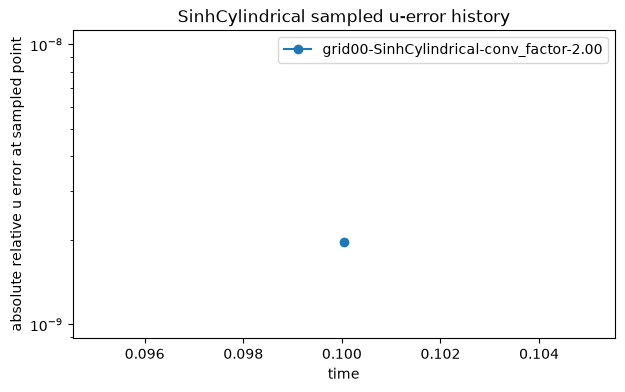

In [23]:
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 4))
for diagnostic, rows in diagnostic_rows.items():
    positive_rows = [row for row in rows if abs(row[1]) > 0.0]
    times = [row[0] for row in positive_rows]
    errors = [abs(row[1]) for row in positive_rows]
    label = diagnostic.stem.replace("out0d-", "")
    plt.plot(times, errors, marker="o", label=label)
plt.yscale("log")
plt.xlabel("time")
plt.ylabel("absolute relative u error at sampled point")
plt.title("SinhCylindrical sampled u-error history")
plt.legend()
plt.show()

The symbolic residuals check the reference-metric wave operator in readable
coordinates. The generated project evidence then shows the default
`SinhCylindrical` source, boundary metadata, executable, diagnostics, and plot.

# What next?
### [Back to [top](#Table-of-Contents)]

- [Curvilinear Boundary Conditions](../4-curvilinear/curvilinear_boundary_conditions.ipynb)
- [GeneralRFM and Fisheye Coordinates](../4-curvilinear/generalrfm_and_fisheye.ipynb)
- [Multicoordinate Wave Project](wave_equation_multicoordinates.ipynb)